In [1]:
from sklearn.datasets      import make_multilabel_classification
from sklearn.metrics       import classification_report
from sklearn.metrics       import label_ranking_loss
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold      import TSNE
import matplotlib.pyplot   as plt

In [2]:
X, y = make_multilabel_classification(n_features      = 5,
                                      length          = 10,
                                      n_samples       = 100,
                                      n_classes       = 4,
                                      n_labels        = 2,
                                      allow_unlabeled = False,
                                      random_state    = 42)
print(X.shape)
print(y.shape)
y[0]

(100, 5)
(100, 4)


array([1, 0, 1, 0])

In [3]:
X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=42).fit_transform(X)

In [4]:
# plt.figure(figsize=(3,3))
# plt.scatter(X_embedded[:,0],X_embedded[:,1],c = y[:,0])
# plt.show()

In [5]:
label_ranking_loss(y,y)

0.0

In [6]:
import torch
torch.manual_seed(seed = 42)

import torch.nn as nn
from torch.utils.data        import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
device = torch.device("cpu") #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)


Device cpu


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).type(torch.float32)
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .type(torch.float32)
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [36]:
import torch.nn.functional as F

In [52]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            #preds = F.sigmoid(preds)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [ ]:
model = nn.Sequential(
    nn.Linear(5, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 4),
    nn.Sigmoid()
); model.to(device)

loss_module = torch.nn.BCELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99)) #(0.1,0.3)

In [100]:
hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 5000)

100%|██████████| 5000/5000 [00:08<00:00, 597.92it/s]


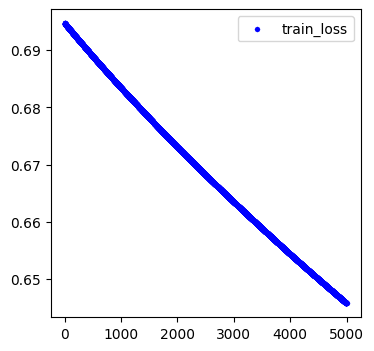

In [101]:
#hist = [float(h.cpu().detach()) for h in hist]
plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()
plt.show()

In [102]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds = model(data_inputs)
        #preds = preds.squeeze(dim=1)
        pred_labels = (preds >= 0.5).long().to(device)
        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels), dim = 0)
    print(classification_report(y_pred =   all_pred.cpu().numpy(), 
                                y_true = all_labels.cpu().numpy(), 
                                target_names  = target_names, 
                                zero_division = 0))


In [ ]:
eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

              precision    recall  f1-score   support

     Label 0       0.00      0.00      0.00         6
     Label 1       0.70      1.00      0.82        14
     Label 2       0.72      1.00      0.84        13
     Label 3       1.00      0.09      0.17        11

   micro avg       0.72      0.64      0.67        44
   macro avg       0.61      0.52      0.46        44
weighted avg       0.69      0.64      0.55        44
 samples avg       0.71      0.65      0.65        44



---

Making sure the eval module is working properly

In [104]:
train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 100, shuffle = False)
X_samples, Y_sample = next(iter(train_loader))
model.eval()

Sequential(
  (0): Linear(in_features=5, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=4, bias=True)
  (5): Sigmoid()
)

In [107]:
z = model(X_samples)
print(z.shape)
z = F.sigmoid(z)
print(z)
z = (z > 0.5).long()
z

torch.Size([80, 4])
tensor([[0.6146, 0.6355, 0.6236, 0.6160],
        [0.6064, 0.6438, 0.6341, 0.6195],
        [0.6014, 0.6463, 0.6349, 0.6295],
        [0.6047, 0.6532, 0.6214, 0.6137],
        [0.5921, 0.6635, 0.6540, 0.5863],
        [0.6026, 0.6512, 0.6437, 0.6044],
        [0.5789, 0.6751, 0.6284, 0.6206],
        [0.5908, 0.6592, 0.6308, 0.6302],
        [0.5893, 0.6636, 0.6346, 0.6104],
        [0.5820, 0.6743, 0.6222, 0.6108],
        [0.5908, 0.6610, 0.6554, 0.5913],
        [0.6006, 0.6484, 0.6352, 0.6156],
        [0.6116, 0.6501, 0.6221, 0.6101],
        [0.5946, 0.6638, 0.6187, 0.6105],
        [0.6005, 0.6431, 0.6329, 0.6181],
        [0.5966, 0.6722, 0.6190, 0.6076],
        [0.6013, 0.6578, 0.6405, 0.5853],
        [0.5989, 0.6648, 0.6205, 0.6040],
        [0.6042, 0.6495, 0.6374, 0.5992],
        [0.6030, 0.6417, 0.6361, 0.6231],
        [0.6036, 0.6492, 0.6269, 0.6192],
        [0.6067, 0.6394, 0.6303, 0.6150],
        [0.6002, 0.6594, 0.6260, 0.5996],
        [0.598

tensor([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1

In [108]:
Y_sample

tensor([[0., 1., 1., 0.],
        [0., 1., 1., 1.],
        [0., 1., 1., 1.],
        [1., 1., 0., 1.],
        [1., 0., 1., 0.],
        [0., 1., 1., 0.],
        [0., 1., 1., 0.],
        [0., 1., 0., 1.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 1., 0.],
        [0., 0., 1., 1.],
        [1., 1., 1., 1.],
        [0., 1., 1., 0.],
        [0., 0., 0., 1.],
        [1., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 1.],
        [1., 1., 1., 1.],
        [0., 1., 1., 1.],
        [1., 1., 0., 0.],
        [0., 0., 1., 1.],
        [1., 0., 1., 0.],
        [0., 1., 1., 1.],
        [1., 1., 1., 0.],
        [1., 1., 1., 0.],
        [0., 1., 0., 0.],
        [1., 1., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [1., 1., 1., 0.],
        [0., 1., 1., 0.],
        [0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0.,

In [109]:
print(classification_report(y_pred     = z.cpu().numpy(), 
                                y_true = Y_sample.cpu().numpy(), 
                                zero_division = 0))

              precision    recall  f1-score   support

           0       0.41      1.00      0.58        33
           1       0.66      1.00      0.80        53
           2       0.59      1.00      0.74        47
           3       0.46      1.00      0.63        37

   micro avg       0.53      1.00      0.69       170
   macro avg       0.53      1.00      0.69       170
weighted avg       0.55      1.00      0.70       170
 samples avg       0.53      1.00      0.67       170

